# Unsupervised Results Analysis

Analyze `data/results/unsupervised.csv` from the unsupervised runner. The notebook ranks anomaly detection experiments, compares model configs, and inspects threshold behavior through FPR/FNR/TPR/TNR.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_PATH = PROJECT_ROOT / "data" / "results" / "unsupervised.csv"
RESULTS_PATH

PosixPath('/Users/paolacalle/Desktop/NYU/semesters/spring-2026/ML/hw/gaming-toxicity-detection/data/results/unsupervised.csv')

In [2]:
df = pd.read_csv(RESULTS_PATH)

numeric_cols = [
    "rows", "accuracy", "f1", "recall", "precision", "fpr", "fnr",
    "tpr", "tnr", "auc", "fit_seconds", "accuracy_std", "f1_std",
    "recall_std", "precision_std", "fpr_std", "fnr_std", "tpr_std",
    "tnr_std", "auc_std", "fit_seconds_std",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["fold"] = df["fold"].fillna("")
df["is_fold"] = df["evaluation"].eq("fold_val")
df["is_summary"] = df["evaluation"].eq("fold_mean")
df["is_holdout"] = df["evaluation"].isin(["val", "test"])

print(df.shape)
df.head()

(72, 34)


,experiment_name,split_method,evaluation,fold,model,model_config,model_experiment,training_mode,rows,accuracy,f1,recall,precision,fpr,fnr,tpr,tnr,auc,fit_seconds,accuracy_std,f1_std,recall_std,precision_std,fpr_std,fnr_std,tpr_std,tnr_std,auc_std,fit_seconds_std,label_counts,prediction_counts,is_fold,is_summary,is_holdout
0,train_only_nontoxic__val__isolation_forest:balanced_flags,train_only_nontoxic,val,,isolation_forest,balanced_flags,isolation_forest:balanced_flags,unsupervised,17064,0.3795,0.0788,0.0424,0.5565,0.0565,0.9576,0.0424,0.9435,0.4715,1.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6384, ""1"": 10680}","{""0"": 16250, ""1"": 814}",False,False,True
1,train_only_nontoxic__test__isolation_forest:balanced_flags,train_only_nontoxic,test,,isolation_forest,balanced_flags,isolation_forest:balanced_flags,unsupervised,17064,0.3753,0.0727,0.0391,0.5123,0.0623,0.9609,0.0391,0.9377,0.4683,1.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6384, ""1"": 10680}","{""0"": 16248, ""1"": 816}",False,False,True
2,train_only_nontoxic__val__isolation_forest:default,train_only_nontoxic,val,,isolation_forest,default,isolation_forest:default,unsupervised,17064,0.3741,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.4715,0.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}",False,False,True
3,train_only_nontoxic__test__isolation_forest:default,train_only_nontoxic,test,,isolation_forest,default,isolation_forest:default,unsupervised,17064,0.3741,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.4683,0.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}",False,False,True
4,train_only_nontoxic__val__isolation_forest:loose,train_only_nontoxic,val,,isolation_forest,loose,isolation_forest:loose,unsupervised,17064,0.4022,0.1907,0.1125,0.6244,0.1133,0.8875,0.1125,0.8867,0.4715,1.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6384, ""1"": 10680}","{""0"": 15139, ""1"": 1925}",False,False,True


## Overview

In [3]:
overview = (
    df.groupby(["model", "model_config", "evaluation"], dropna=False)
      .agg(
          runs=("experiment_name", "count"),
          mean_f1=("f1", "mean"),
          mean_auc=("auc", "mean"),
          mean_tpr=("tpr", "mean"),
          mean_fpr=("fpr", "mean"),
          mean_fit_seconds=("fit_seconds", "mean"),
      )
      .reset_index()
      .sort_values(["evaluation", "mean_f1"], ascending=[True, False])
)
overview

,model,model_config,evaluation,runs,mean_f1,mean_auc,mean_tpr,mean_fpr,mean_fit_seconds
28,sgd_one_class_svm,loose,fold_mean,1,0.23050,0.56900,0.21860,0.12610,0.262
20,sgd_one_class_svm,balanced_flags,fold_mean,1,0.17630,0.56150,0.15160,0.10570,0.262
24,sgd_one_class_svm,default,fold_mean,1,0.17630,0.56150,0.15160,0.10570,0.268
8,isolation_forest,loose,fold_mean,1,0.14650,0.50060,0.12960,0.11910,1.358
0,isolation_forest,balanced_flags,fold_mean,1,0.08150,0.50060,0.05660,0.06090,1.354
16,isolation_forest,strict,fold_mean,1,0.03040,0.50060,0.01670,0.01440,1.354
4,isolation_forest,default,fold_mean,1,0.00000,0.50060,0.00000,0.00000,0.870
12,isolation_forest,more_trees,fold_mean,1,0.00000,0.50450,0.00000,0.00000,1.408
32,sgd_one_class_svm,strict,fold_mean,1,0.00000,0.58130,0.00000,0.00000,0.264
29,sgd_one_class_svm,loose,fold_val,5,0.23050,0.56898,0.21862,0.12608,0.262


## Holdout Ranking

In [4]:
holdout = df[df["is_holdout"]].copy()

rank_cols = [
    "experiment_name", "evaluation", "model", "model_config", "rows",
    "f1", "auc", "precision", "recall", "fpr", "fnr", "tpr", "tnr",
    "fit_seconds", "label_counts", "prediction_counts",
]
holdout_ranked = holdout.sort_values(["evaluation", "f1", "auc"], ascending=[True, False, False])
holdout_ranked[rank_cols].head(20)

,experiment_name,evaluation,model,model_config,rows,f1,auc,precision,recall,fpr,fnr,tpr,tnr,fit_seconds,label_counts,prediction_counts
15,train_only_nontoxic__test__sgd_one_class_svm:loose,test,sgd_one_class_svm,loose,17064,0.3339,0.5699,0.7435,0.2153,0.1242,0.7847,0.2153,0.8758,0.31,"{""0"": 6384, ""1"": 10680}","{""0"": 13972, ""1"": 3092}"
11,train_only_nontoxic__test__sgd_one_class_svm:balanced_flags,test,sgd_one_class_svm,balanced_flags,17064,0.2389,0.5510,0.7021,0.1439,0.1021,0.8561,0.1439,0.8979,0.31,"{""0"": 6384, ""1"": 10680}","{""0"": 14875, ""1"": 2189}"
13,train_only_nontoxic__test__sgd_one_class_svm:default,test,sgd_one_class_svm,default,17064,0.2389,0.5510,0.7021,0.1439,0.1021,0.8561,0.1439,0.8979,0.32,"{""0"": 6384, ""1"": 10680}","{""0"": 14875, ""1"": 2189}"
5,train_only_nontoxic__test__isolation_forest:loose,test,isolation_forest,loose,17064,0.1924,0.4683,0.6148,0.1140,0.1195,0.8860,0.1140,0.8805,1.59,"{""0"": 6384, ""1"": 10680}","{""0"": 15083, ""1"": 1981}"
1,train_only_nontoxic__test__isolation_forest:balanced_flags,test,isolation_forest,balanced_flags,17064,0.0727,0.4683,0.5123,0.0391,0.0623,0.9609,0.0391,0.9377,1.59,"{""0"": 6384, ""1"": 10680}","{""0"": 16248, ""1"": 816}"
9,train_only_nontoxic__test__isolation_forest:strict,test,isolation_forest,strict,17064,0.0126,0.4683,0.4359,0.0064,0.0138,0.9936,0.0064,0.9862,1.58,"{""0"": 6384, ""1"": 10680}","{""0"": 16908, ""1"": 156}"
17,train_only_nontoxic__test__sgd_one_class_svm:strict,test,sgd_one_class_svm,strict,17064,0.0000,0.5537,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.31,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}"
7,train_only_nontoxic__test__isolation_forest:more_trees,test,isolation_forest,more_trees,17064,0.0000,0.4946,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.63,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}"
3,train_only_nontoxic__test__isolation_forest:default,test,isolation_forest,default,17064,0.0000,0.4683,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.98,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}"
14,train_only_nontoxic__val__sgd_one_class_svm:loose,val,sgd_one_class_svm,loose,17064,0.3383,0.5715,0.7411,0.2192,0.1281,0.7808,0.2192,0.8719,0.33,"{""0"": 6384, ""1"": 10680}","{""0"": 13905, ""1"": 3159}"


In [5]:
test_ranked = holdout[holdout["evaluation"].eq("test")].sort_values(["f1", "auc"], ascending=False)
test_ranked[rank_cols].head(15)

,experiment_name,evaluation,model,model_config,rows,f1,auc,precision,recall,fpr,fnr,tpr,tnr,fit_seconds,label_counts,prediction_counts
15,train_only_nontoxic__test__sgd_one_class_svm:loose,test,sgd_one_class_svm,loose,17064,0.3339,0.5699,0.7435,0.2153,0.1242,0.7847,0.2153,0.8758,0.31,"{""0"": 6384, ""1"": 10680}","{""0"": 13972, ""1"": 3092}"
11,train_only_nontoxic__test__sgd_one_class_svm:balanced_flags,test,sgd_one_class_svm,balanced_flags,17064,0.2389,0.5510,0.7021,0.1439,0.1021,0.8561,0.1439,0.8979,0.31,"{""0"": 6384, ""1"": 10680}","{""0"": 14875, ""1"": 2189}"
13,train_only_nontoxic__test__sgd_one_class_svm:default,test,sgd_one_class_svm,default,17064,0.2389,0.5510,0.7021,0.1439,0.1021,0.8561,0.1439,0.8979,0.32,"{""0"": 6384, ""1"": 10680}","{""0"": 14875, ""1"": 2189}"
5,train_only_nontoxic__test__isolation_forest:loose,test,isolation_forest,loose,17064,0.1924,0.4683,0.6148,0.1140,0.1195,0.8860,0.1140,0.8805,1.59,"{""0"": 6384, ""1"": 10680}","{""0"": 15083, ""1"": 1981}"
1,train_only_nontoxic__test__isolation_forest:balanced_flags,test,isolation_forest,balanced_flags,17064,0.0727,0.4683,0.5123,0.0391,0.0623,0.9609,0.0391,0.9377,1.59,"{""0"": 6384, ""1"": 10680}","{""0"": 16248, ""1"": 816}"
9,train_only_nontoxic__test__isolation_forest:strict,test,isolation_forest,strict,17064,0.0126,0.4683,0.4359,0.0064,0.0138,0.9936,0.0064,0.9862,1.58,"{""0"": 6384, ""1"": 10680}","{""0"": 16908, ""1"": 156}"
17,train_only_nontoxic__test__sgd_one_class_svm:strict,test,sgd_one_class_svm,strict,17064,0.0000,0.5537,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.31,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}"
7,train_only_nontoxic__test__isolation_forest:more_trees,test,isolation_forest,more_trees,17064,0.0000,0.4946,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.63,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}"
3,train_only_nontoxic__test__isolation_forest:default,test,isolation_forest,default,17064,0.0000,0.4683,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.98,"{""0"": 6384, ""1"": 10680}","{""0"": 17064}"


## Metric Tradeoffs

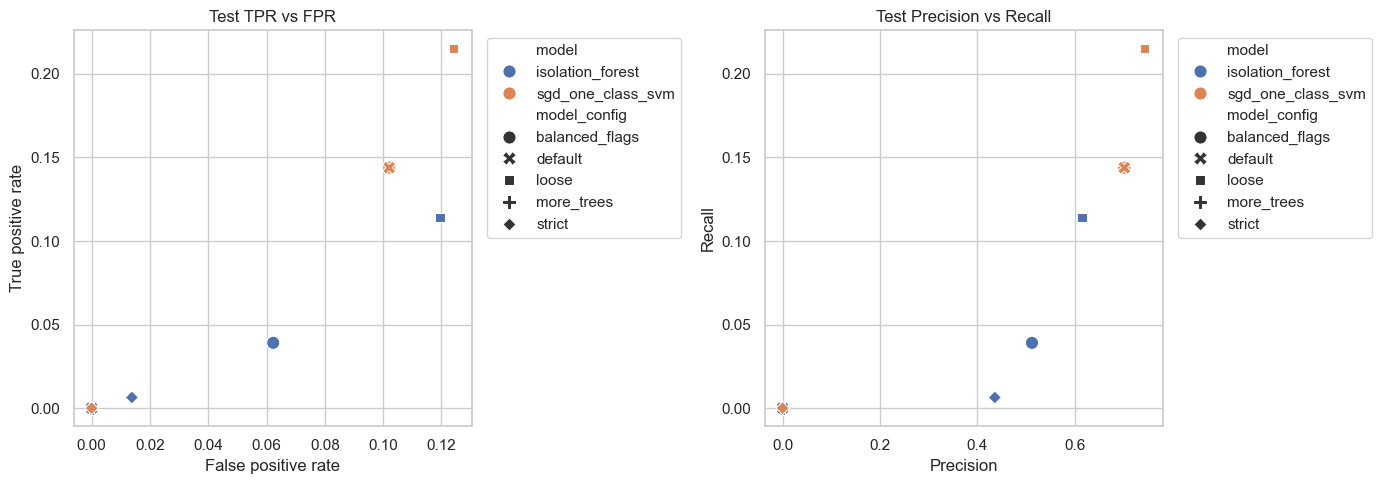

In [6]:
plot_df = holdout[holdout["evaluation"].eq("test")].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_df,
    x="fpr",
    y="tpr",
    hue="model",
    style="model_config",
    s=90,
    ax=axes[0],
)
axes[0].set_title("Test TPR vs FPR")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")

sns.scatterplot(
    data=plot_df,
    x="precision",
    y="recall",
    hue="model",
    style="model_config",
    s=90,
    ax=axes[1],
)
axes[1].set_title("Test Precision vs Recall")
axes[1].set_xlabel("Precision")
axes[1].set_ylabel("Recall")

for ax in axes:
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

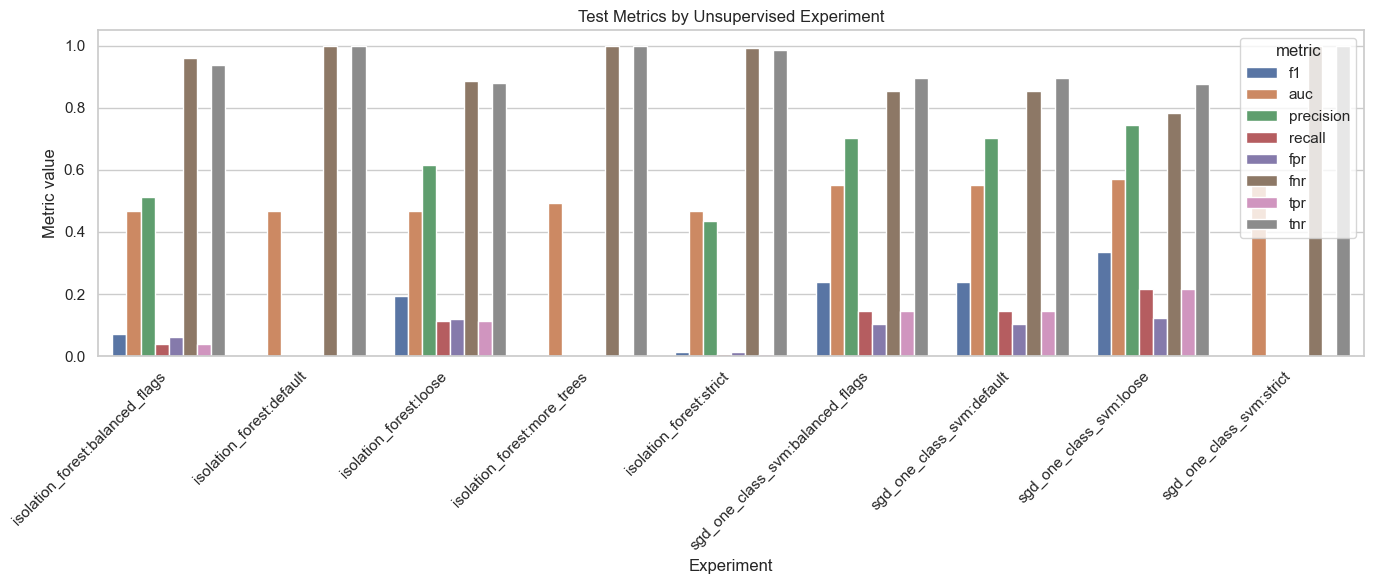

In [7]:
metric_long = plot_df.melt(
    id_vars=["model", "model_config", "model_experiment"],
    value_vars=["f1", "auc", "precision", "recall", "fpr", "fnr", "tpr", "tnr"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=metric_long, x="model_experiment", y="value", hue="metric")
plt.xticks(rotation=45, ha="right")
plt.title("Test Metrics by Unsupervised Experiment")
plt.xlabel("Experiment")
plt.ylabel("Metric value")
plt.tight_layout()

## Fold Stability

In [8]:
fold_summary = df[df["is_summary"]].copy()
fold_cols = [
    "model", "model_config", "model_experiment", "rows", "f1", "f1_std",
    "auc", "auc_std", "precision", "precision_std", "recall", "recall_std",
    "fpr", "fpr_std", "fnr", "fnr_std", "fit_seconds", "fit_seconds_std",
]
fold_summary[fold_cols].sort_values(["f1", "auc"], ascending=False)

,model,model_config,model_experiment,rows,f1,f1_std,auc,auc_std,precision,precision_std,recall,recall_std,fpr,fpr_std,fnr,fnr_std,fit_seconds,fit_seconds_std
70,sgd_one_class_svm,loose,sgd_one_class_svm:loose,68135,0.2305,0.0088,0.5690,0.0072,0.2439,0.0100,0.2186,0.0090,0.1261,0.0046,0.7814,0.0090,0.262,0.0040
68,sgd_one_class_svm,balanced_flags,sgd_one_class_svm:balanced_flags,68135,0.1763,0.0077,0.5615,0.0122,0.2107,0.0109,0.1516,0.0058,0.1057,0.0032,0.8484,0.0058,0.262,0.0040
69,sgd_one_class_svm,default,sgd_one_class_svm:default,68135,0.1763,0.0077,0.5615,0.0122,0.2107,0.0109,0.1516,0.0058,0.1057,0.0032,0.8484,0.0058,0.268,0.0075
65,isolation_forest,loose,isolation_forest:loose,68135,0.1465,0.0096,0.5006,0.0222,0.1684,0.0119,0.1296,0.0081,0.1191,0.0036,0.8704,0.0081,1.358,0.0194
63,isolation_forest,balanced_flags,isolation_forest:balanced_flags,68135,0.0815,0.0248,0.5006,0.0222,0.1455,0.0390,0.0566,0.0180,0.0609,0.0017,0.9434,0.0180,1.354,0.0273
67,isolation_forest,strict,isolation_forest:strict,68135,0.0304,0.0093,0.5006,0.0222,0.1736,0.0433,0.0167,0.0052,0.0144,0.0017,0.9833,0.0052,1.354,0.0206
71,sgd_one_class_svm,strict,sgd_one_class_svm:strict,68135,0.0000,0.0000,0.5813,0.0118,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.264,0.0049
66,isolation_forest,more_trees,isolation_forest:more_trees,68135,0.0000,0.0000,0.5045,0.0118,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.408,0.0223
64,isolation_forest,default,isolation_forest:default,68135,0.0000,0.0000,0.5006,0.0222,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.870,0.0405


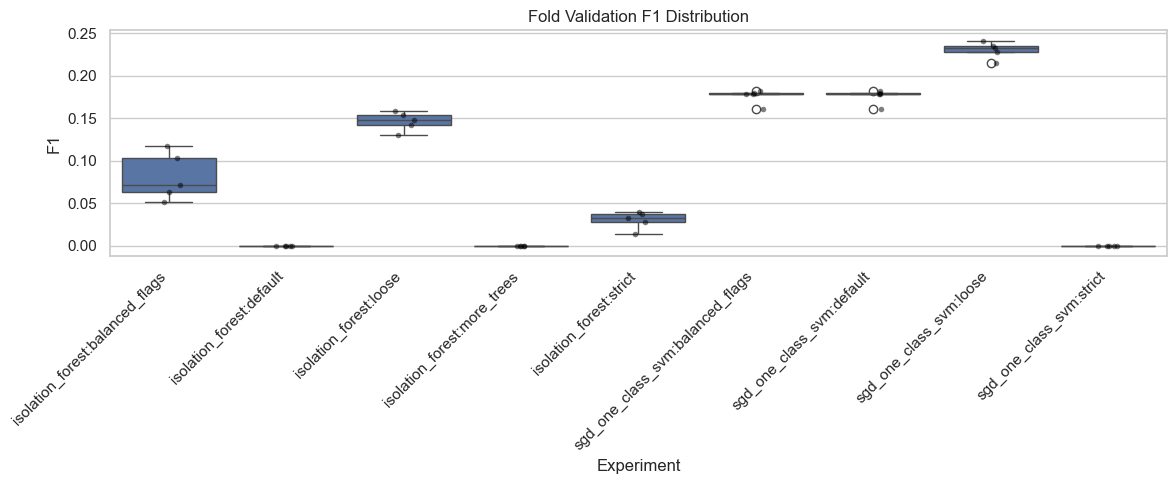

In [9]:
folds = df[df["is_fold"]].copy()

plt.figure(figsize=(12, 5))
sns.boxplot(data=folds, x="model_experiment", y="f1")
sns.stripplot(data=folds, x="model_experiment", y="f1", color="black", alpha=0.5, size=4)
plt.xticks(rotation=45, ha="right")
plt.title("Fold Validation F1 Distribution")
plt.xlabel("Experiment")
plt.ylabel("F1")
plt.tight_layout()

## Prediction Volume

In [13]:
def parse_counts(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    return json.loads(value)

pred_counts = holdout.copy()
pred_counts["predicted_normal"] = pred_counts["prediction_counts"].apply(lambda x: parse_counts(x).get("0", 0))
pred_counts["predicted_anomaly"] = pred_counts["prediction_counts"].apply(lambda x: parse_counts(x).get("1", 0))
pred_counts["predicted_anomaly_rate"] = pred_counts["predicted_anomaly"] / pred_counts["rows"]

# anamoly and right 
pred_counts["anomaly_and_right"] = pred_counts.apply(
    lambda row: min(parse_counts(row["label_counts"]).get("1", 0), parse_counts(row["prediction_counts"]).get("1", 0)),
    axis=1
)
pred_counts["anomaly_and_right_rate"] = pred_counts["anomaly_and_right"] / pred_counts["rows"]

pred_counts[[
    "experiment_name", "evaluation", "model", "model_config", "rows",
    "predicted_anomaly", "predicted_anomaly_rate", "anomaly_and_right", "anomaly_and_right_rate", "fpr", "tpr", "precision", "recall", "f1",
]].sort_values(["evaluation", "predicted_anomaly_rate"], ascending=[True, False])

,experiment_name,evaluation,model,model_config,rows,predicted_anomaly,predicted_anomaly_rate,anomaly_and_right,anomaly_and_right_rate,fpr,tpr,precision,recall,f1
15,train_only_nontoxic__test__sgd_one_class_svm:loose,test,sgd_one_class_svm,loose,17064,3092,0.181200,3092,0.181200,0.1242,0.2153,0.7435,0.2153,0.3339
11,train_only_nontoxic__test__sgd_one_class_svm:balanced_flags,test,sgd_one_class_svm,balanced_flags,17064,2189,0.128282,2189,0.128282,0.1021,0.1439,0.7021,0.1439,0.2389
13,train_only_nontoxic__test__sgd_one_class_svm:default,test,sgd_one_class_svm,default,17064,2189,0.128282,2189,0.128282,0.1021,0.1439,0.7021,0.1439,0.2389
5,train_only_nontoxic__test__isolation_forest:loose,test,isolation_forest,loose,17064,1981,0.116092,1981,0.116092,0.1195,0.1140,0.6148,0.1140,0.1924
1,train_only_nontoxic__test__isolation_forest:balanced_flags,test,isolation_forest,balanced_flags,17064,816,0.047820,816,0.047820,0.0623,0.0391,0.5123,0.0391,0.0727
9,train_only_nontoxic__test__isolation_forest:strict,test,isolation_forest,strict,17064,156,0.009142,156,0.009142,0.0138,0.0064,0.4359,0.0064,0.0126
3,train_only_nontoxic__test__isolation_forest:default,test,isolation_forest,default,17064,0,0.000000,0,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000
7,train_only_nontoxic__test__isolation_forest:more_trees,test,isolation_forest,more_trees,17064,0,0.000000,0,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000
17,train_only_nontoxic__test__sgd_one_class_svm:strict,test,sgd_one_class_svm,strict,17064,0,0.000000,0,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000
14,train_only_nontoxic__val__sgd_one_class_svm:loose,val,sgd_one_class_svm,loose,17064,3159,0.185127,3159,0.185127,0.1281,0.2192,0.7411,0.2192,0.3383


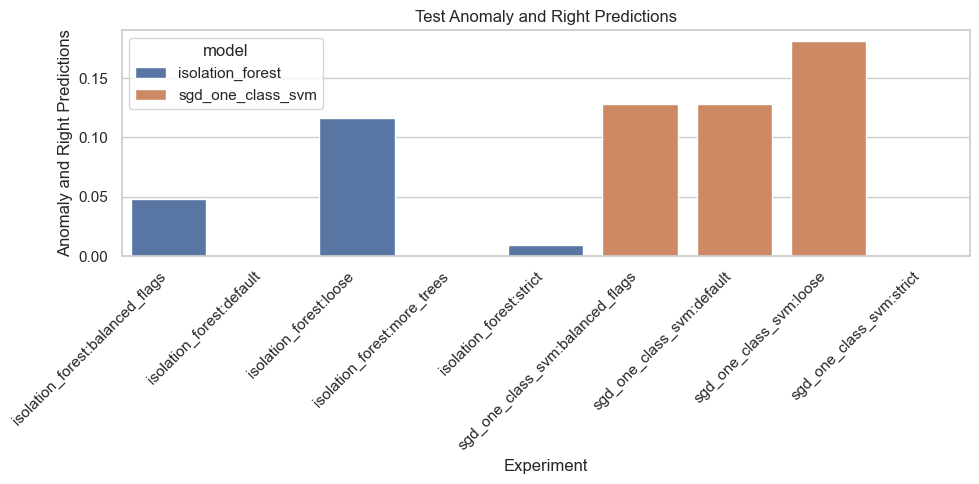

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=pred_counts[pred_counts["evaluation"].eq("test")],
    x="model_experiment",
    y="anomaly_and_right_rate",
    hue="model",
    dodge=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("Test Anomaly and Right Predictions")
plt.xlabel("Experiment")
plt.ylabel("Anomaly and Right Predictions")
plt.tight_layout()

## Summary

The strongest unsupervised result is `sgd_one_class_svm:loose`. On the test split it reaches F1 `0.3339`, AUC `0.5699`, precision `0.7435`, and recall `0.2153`. This means the model is conservative: when it flags a message as anomalous/toxic it is often correct, but it misses most toxic examples.

Across the unsupervised experiments, false negative rates are high. The best test model still has FNR `0.7847`, so roughly four out of five toxic examples are not flagged. This makes the current unsupervised setup weak as a standalone toxicity detector if recall matters.

`SGDOneClassSVM` is consistently better than `IsolationForest` for this TF-IDF representation. `IsolationForest` often predicts almost everything as normal, especially the `default`, `more_trees`, and `strict` configs, which produce near-zero recall and F1.

The `loose` configs improve recall by allowing more anomaly flags, but they also increase FPR. For example, `sgd_one_class_svm:loose` has the best test F1 but also the highest FPR among the top unsupervised runs. The tradeoff is acceptable only if catching more toxic examples matters more than avoiding false alarms.

Overall, these results suggest unsupervised normal-only training is useful as a high-precision anomaly signal, but not enough for primary toxicity classification. The next step should be comparing this against supervised models and possibly using unsupervised scores as an additional feature or triage signal rather than as the final classifier.